# 📱 SMS Spam / Ham Detection
### TF-IDF + Logistic Regression Pipeline
---

## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

print('All imports successful ✅')

All imports successful ✅


## 2. Load & Explore the Dataset

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# Load dataset — adjust path if needed
df = pd.read_csv('/content/drive/MyDrive/spam_ham /spam.csv', encoding='latin-1')

# Keep only the two relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(f'Shape: {df.shape}')
df.head()

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64


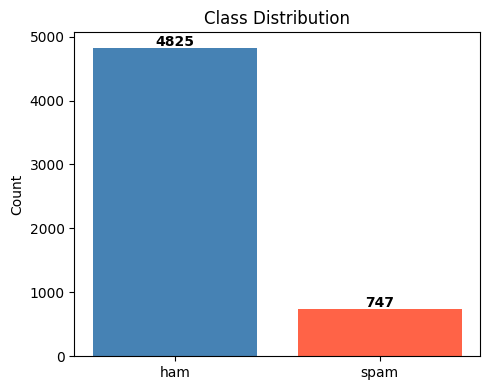

In [14]:
# Class distribution
print(df['label'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
counts = df['label'].value_counts()
ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

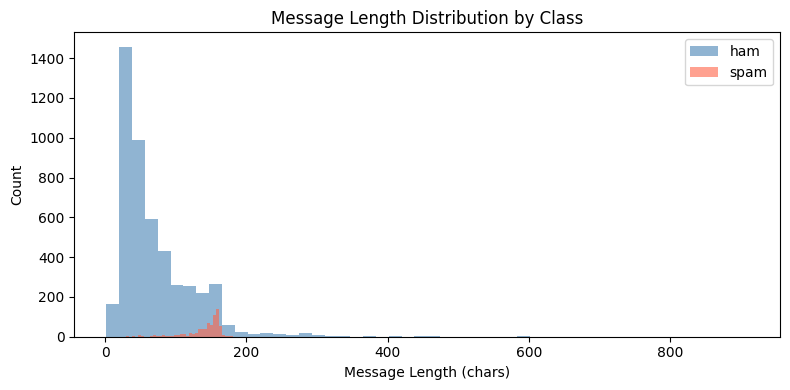

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [15]:
# Message length analysis
df['msg_length'] = df['message'].apply(len)

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [('ham', 'steelblue'), ('spam', 'tomato')]:
    subset = df[df['label'] == label]['msg_length']
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=color)
ax.set_title('Message Length Distribution by Class')
ax.set_xlabel('Message Length (chars)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('label')['msg_length'].describe())

## 3. Preprocessing

In [17]:
# Drop missing values
df.dropna(subset=['label', 'message'], inplace=True)
print(f'After dropping NAs: {df.shape}')

# Encode labels: ham=0, spam=1
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
print(df['label_enc'].value_counts())

After dropping NAs: (5572, 4)
label_enc
0    4825
1     747
Name: count, dtype: int64


In [18]:
# Train/test split — 80/20
X = df['message']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 4457 | Test size: 1115


## 4. TF-IDF Vectorization

In [19]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')

Vocabulary size: 7440
TF-IDF matrix shape (train): (4457, 7440)


## 5. Model Training — Logistic Regression

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print('Model trained ✅')

Model trained ✅


## 6. Evaluation

In [21]:
y_pred      = model.predict(X_test_tfidf)
y_pred_prob = model.predict_proba(X_test_tfidf)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Accuracy: 0.9677

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



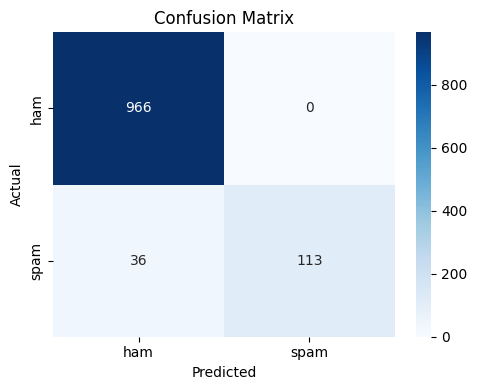

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

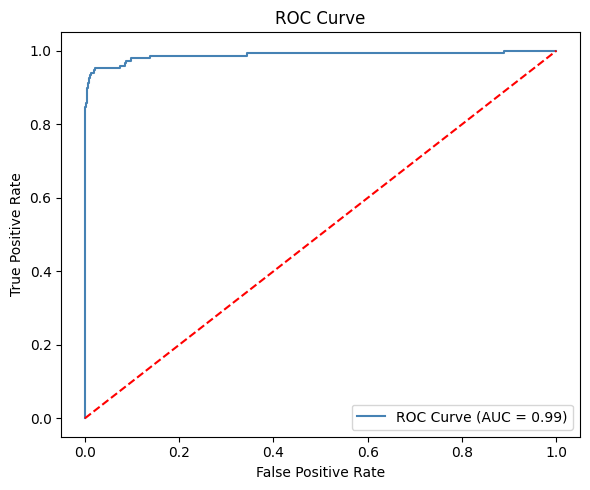

In [23]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

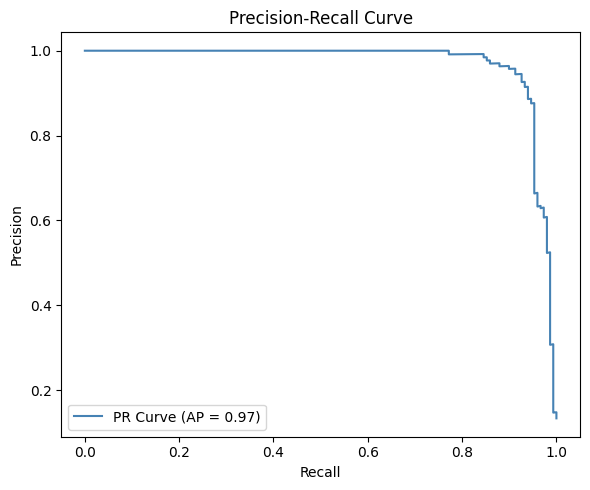

In [24]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
ap = average_precision_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color='steelblue', label=f'PR Curve (AP = {ap:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.show()

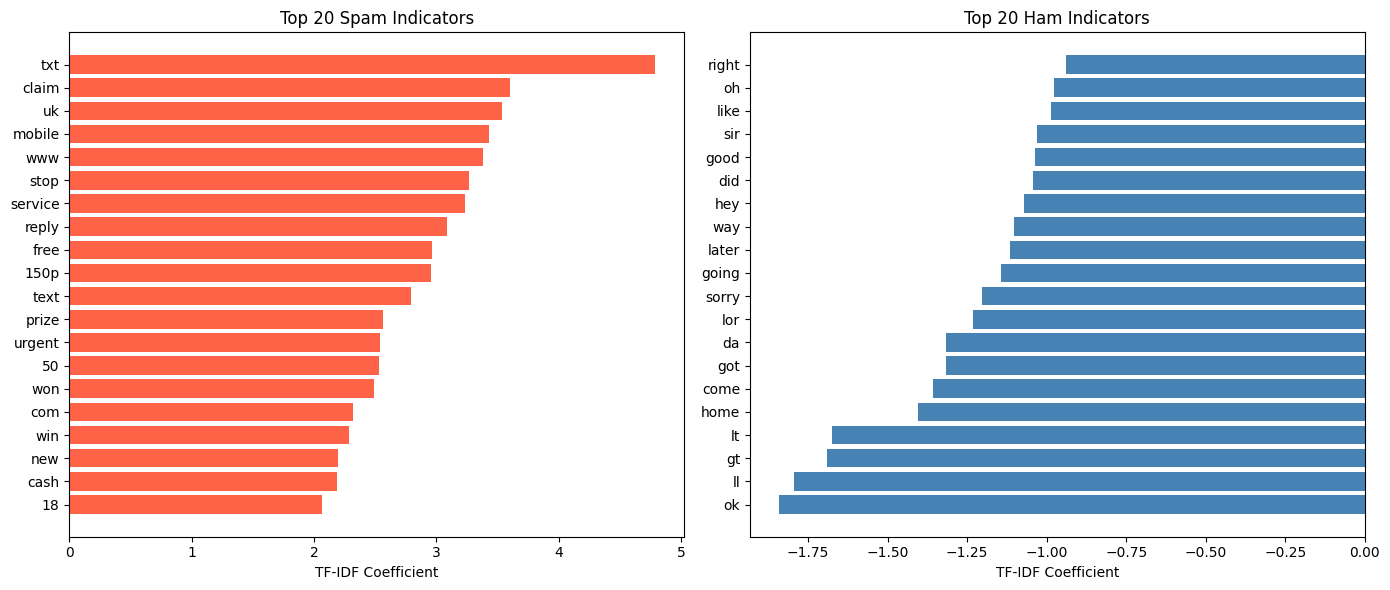

In [25]:
# Top spam-indicator words
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_n = 20
top_spam_idx = coef.argsort()[-top_n:][::-1]
top_ham_idx  = coef.argsort()[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[top_spam_idx][::-1],
             coef[top_spam_idx][::-1], color='tomato')
axes[0].set_title('Top 20 Spam Indicators')
axes[0].set_xlabel('TF-IDF Coefficient')

axes[1].barh(feature_names[top_ham_idx],
             coef[top_ham_idx], color='steelblue')
axes[1].set_title('Top 20 Ham Indicators')
axes[1].set_xlabel('TF-IDF Coefficient')

plt.tight_layout()
plt.show()

## 7. Save the Model

In [26]:
joblib.dump(model,      'spam_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print('Model and vectorizer saved ✅')

Model and vectorizer saved ✅


## 8. Predict on New Messages

In [27]:
def predict_message(text):
    """Classify a single SMS message as ham or spam."""
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]
    label = 'SPAM 🚨' if pred == 1 else 'HAM ✅'
    print(f'Message : "{text}"')
    print(f'Prediction : {label}  (spam probability: {prob:.2%})\n')

# Try a few examples
predict_message("Congratulations! You've won a FREE iPhone. Click now to claim!")
predict_message("Hey, are we still on for dinner tonight?")
predict_message("URGENT: Your bank account has been compromised. Call 0800-FREE now.")
predict_message("Can you pick up the kids from school today?")

Message : "Congratulations! You've won a FREE iPhone. Click now to claim!"
Prediction : SPAM 🚨  (spam probability: 61.45%)

Message : "Hey, are we still on for dinner tonight?"
Prediction : HAM ✅  (spam probability: 2.86%)

Message : "URGENT: Your bank account has been compromised. Call 0800-FREE now."
Prediction : SPAM 🚨  (spam probability: 52.46%)

Message : "Can you pick up the kids from school today?"
Prediction : HAM ✅  (spam probability: 4.64%)

